# Strategy Discovery: Weather Features for Corn Futures

**Goal**: Start from raw data — corn futures prices and Corn Belt weather — explore the relationship between weather and prices, and derive features that could be useful for a trading signal.

**Approach**:
1. Load raw data directly from the warehouse (no pre-built features)
2. Understand the data: what do prices and weather look like?
3. Look for patterns between weather conditions and price movements
4. Construct candidate features based on what we observe
5. Test which features carry useful information (and which don't)
6. Formulate and backtest a signal hypothesis
7. Compare against standard technical baselines

**Data**: Daily corn futures (CBOT ZC=F) and Corn Belt daily precipitation and temperature (Iowa, Illinois, Nebraska), 2010-2026.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats as sp_stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

from etl.db import load_prices, load_raw_data
from strategies.backtest import run_backtest

In [2]:
# Load corn futures prices directly from the warehouse
prices = load_prices('ZC=F')

# Load raw weather for each Corn Belt state
iowa = load_raw_data('weather_daily', 'state', 'Iowa').set_index('date').drop(columns=['state'])
illinois = load_raw_data('weather_daily', 'state', 'Illinois').set_index('date').drop(columns=['state'])
nebraska = load_raw_data('weather_daily', 'state', 'Nebraska').set_index('date').drop(columns=['state'])

# Corn Belt aggregate: simple mean across the three states
weather = pd.concat([iowa, illinois, nebraska]).groupby('date').mean()
weather.columns = ['temp_max', 'temp_min', 'precip']

print(f'Prices:  {len(prices):,} trading days, {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Weather: {len(weather):,} calendar days, {weather.index.min().date()} to {weather.index.max().date()}')
print(f'\nPrice columns: {list(prices.columns)}')
print(f'Weather columns: {list(weather.columns)}')

Prices:  4,068 trading days, 2010-01-04 to 2026-03-11
Weather: 5,913 calendar days, 2010-01-01 to 2026-03-10

Price columns: ['Open', 'High', 'Low', 'Close', 'Volume']
Weather columns: ['temp_max', 'temp_min', 'precip']


## 1. Raw Data Overview

Before constructing any features, look at what we have.

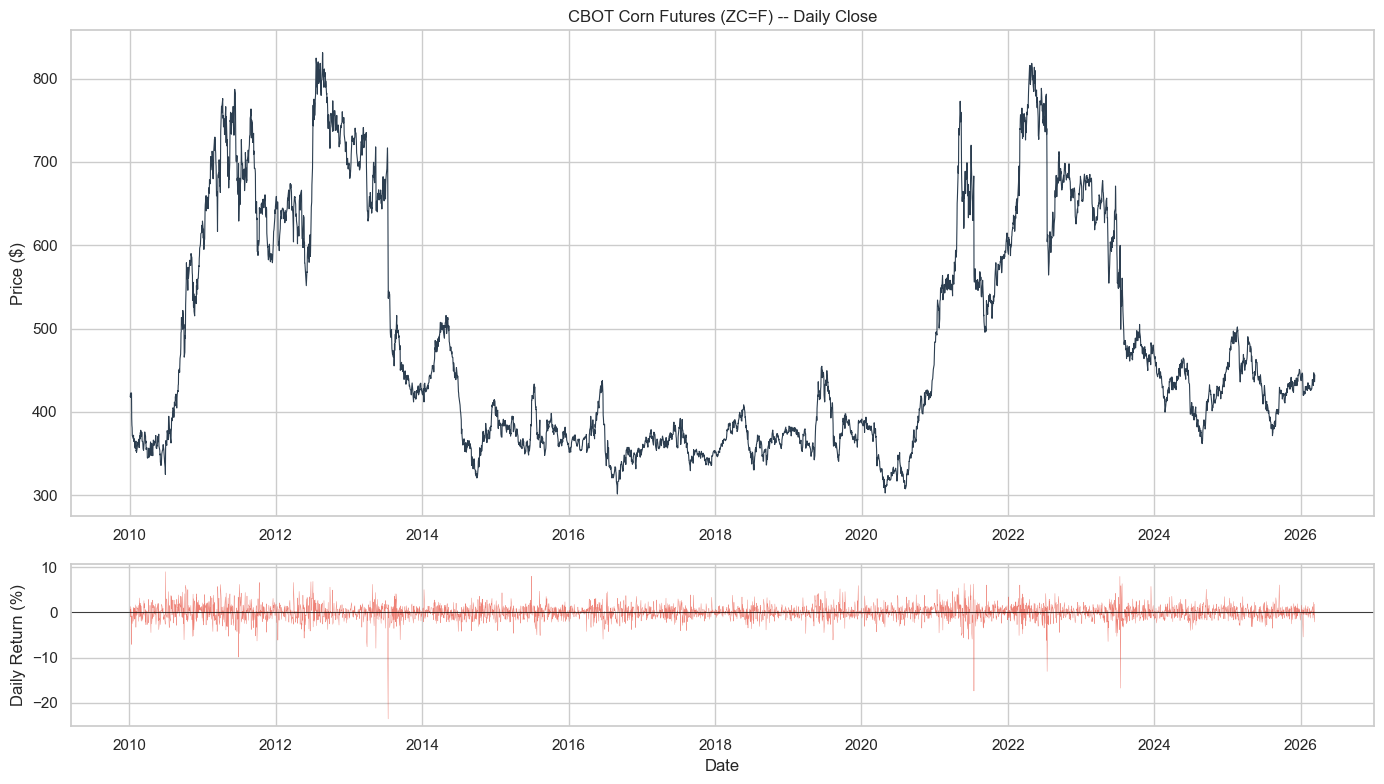

Mean daily return:     0.0164%
Median daily return:   0.0000%
Std daily return:      1.71%
Annualized volatility: 27.2%
Trading days:          4,068


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(prices.index, prices['Close'], linewidth=0.8, color='#2c3e50')
axes[0].set_title('CBOT Corn Futures (ZC=F) -- Daily Close')
axes[0].set_ylabel('Price ($)')

daily_ret = prices['Close'].pct_change()

axes[1].plot(daily_ret.index, daily_ret * 100, linewidth=0.3, color='#e74c3c', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f'Mean daily return:     {daily_ret.mean()*100:.4f}%')
print(f'Median daily return:   {daily_ret.median()*100:.4f}%')
print(f'Std daily return:      {daily_ret.std()*100:.2f}%')
print(f'Annualized volatility: {daily_ret.std()*np.sqrt(252)*100:.1f}%')
print(f'Trading days:          {len(prices):,}')

## 2. Corn Belt Weather Patterns

What does the weather data actually look like? We summarize the key statistics
and seasonal structure before looking for relationships with prices.

In [4]:
# Summary statistics for the weather data
print('=== Corn Belt Weather Summary (3-state avg: Iowa, Illinois, Nebraska) ===')
print(f'Period: {weather.index.min().date()} to {weather.index.max().date()} ({len(weather):,} days)\n')

print('Daily precipitation (inches):')
print(f'  Mean:   {weather["precip"].mean():.3f}')
print(f'  Median: {weather["precip"].median():.3f}')
print(f'  Max:    {weather["precip"].max():.3f}')
print(f'  Dry days (<0.01 in): {(weather["precip"] < 0.01).sum():,} '
      f'({(weather["precip"] < 0.01).mean()*100:.1f}%)')

print(f'\nDaily max temperature (F):')
print(f'  Mean:   {weather["temp_max"].mean():.1f}')
print(f'  Min:    {weather["temp_max"].min():.1f}')
print(f'  Max:    {weather["temp_max"].max():.1f}')
print(f'  Days above 95F: {(weather["temp_max"] > 95).sum():,} '
      f'({(weather["temp_max"] > 95).mean()*100:.1f}%)')

print(f'\nDaily min temperature (F):')
print(f'  Mean:   {weather["temp_min"].mean():.1f}')
print(f'  Min:    {weather["temp_min"].min():.1f}')
print(f'  Max:    {weather["temp_min"].max():.1f}')
print(f'  Days below 32F: {(weather["temp_min"] < 32).sum():,} '
      f'({(weather["temp_min"] < 32).mean()*100:.1f}%)')

# Growing season vs off-season comparison
growing = weather[weather.index.month.isin([5, 6, 7, 8, 9])]
off = weather[~weather.index.month.isin([5, 6, 7, 8, 9])]

print(f'\n--- Growing Season (May-Sep) vs Off-Season ---')
print(f'  {"":20s} {"Growing":>10s} {"Off-Season":>12s}')
print(f'  {"Avg daily precip":20s} {growing["precip"].mean():>10.3f} {off["precip"].mean():>12.3f} in')
print(f'  {"Avg max temp":20s} {growing["temp_max"].mean():>10.1f} {off["temp_max"].mean():>12.1f} F')
print(f'  {"Avg min temp":20s} {growing["temp_min"].mean():>10.1f} {off["temp_min"].mean():>12.1f} F')
print(f'  {"Days":20s} {len(growing):>10,} {len(off):>12,}')

=== Corn Belt Weather Summary (3-state avg: Iowa, Illinois, Nebraska) ===
Period: 2010-01-01 to 2026-03-10 (5,913 days)

Daily precipitation (inches):
  Mean:   0.096
  Median: 0.012
  Max:    1.745
  Dry days (<0.01 in): 2,848 (48.2%)

Daily max temperature (F):
  Mean:   62.1
  Min:    -7.8
  Max:    102.3
  Days above 95F: 50 (0.8%)

Daily min temperature (F):
  Mean:   44.5
  Min:    -17.9
  Max:    83.7
  Days below 32F: 1,773 (30.0%)

--- Growing Season (May-Sep) vs Off-Season ---
                          Growing   Off-Season
  Avg daily precip          0.123        0.077 in
  Avg max temp               81.1         48.7 F
  Avg min temp               63.3         31.3 F
  Days                      2,448        3,465


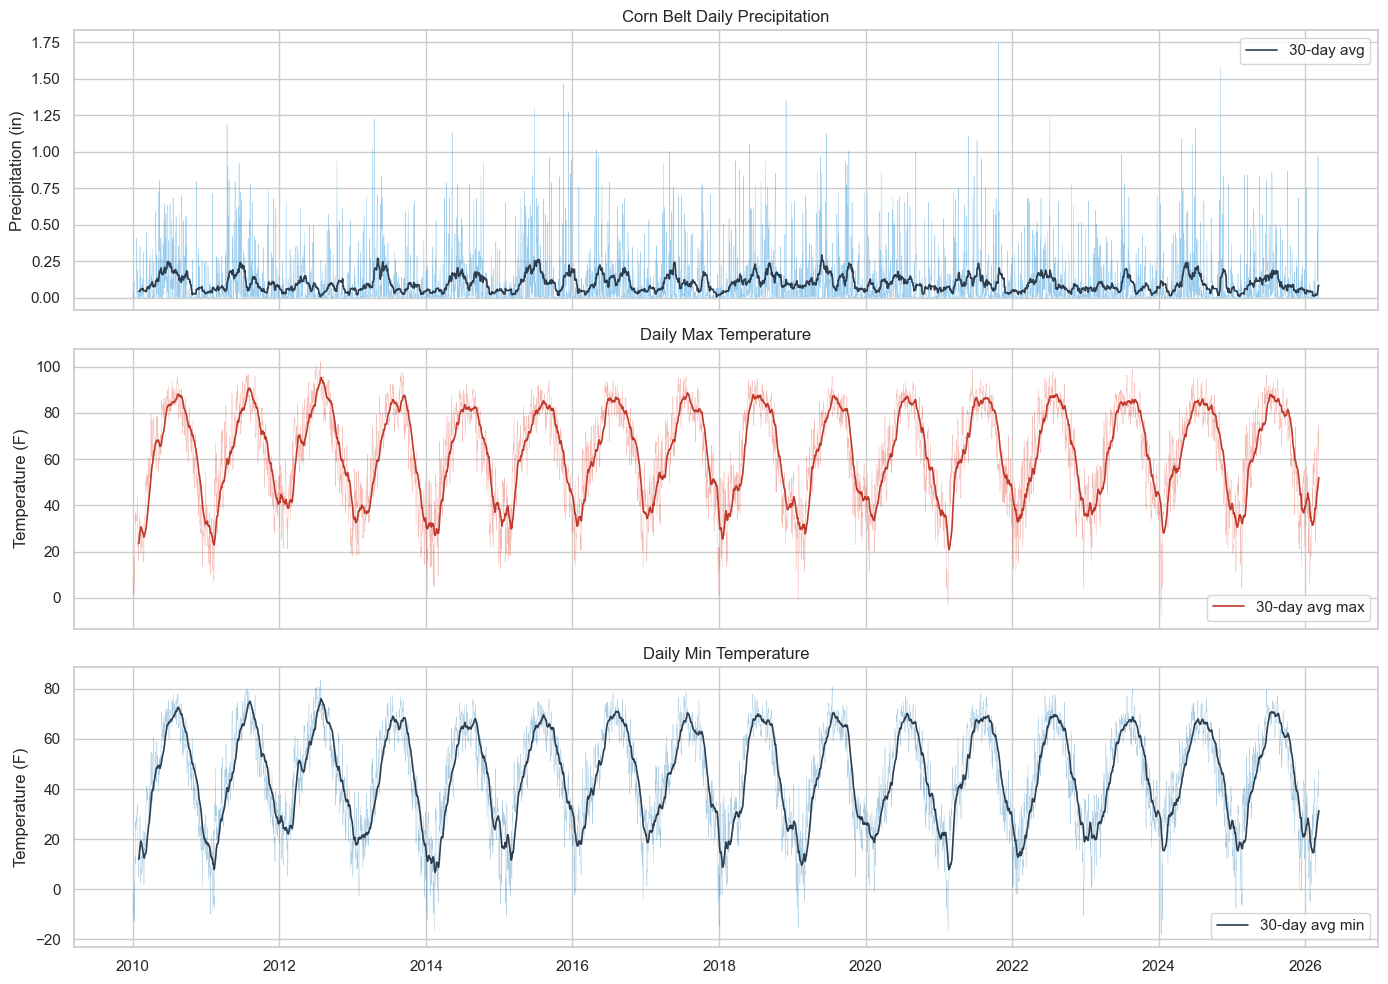

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weather.index, weather['precip'], linewidth=0.3, alpha=0.5, color='#3498db')
axes[0].plot(weather.index, weather['precip'].rolling(30).mean(), linewidth=1.2,
             color='#2c3e50', label='30-day avg')
axes[0].set_ylabel('Precipitation (in)')
axes[0].set_title('Corn Belt Daily Precipitation')
axes[0].legend()

axes[1].plot(weather.index, weather['temp_max'], linewidth=0.3, alpha=0.4, color='#e74c3c')
axes[1].plot(weather.index, weather['temp_max'].rolling(30).mean(), linewidth=1.2,
             color='#c0392b', label='30-day avg max')
axes[1].set_ylabel('Temperature (F)')
axes[1].set_title('Daily Max Temperature')
axes[1].legend()

axes[2].plot(weather.index, weather['temp_min'], linewidth=0.3, alpha=0.4, color='#2980b9')
axes[2].plot(weather.index, weather['temp_min'].rolling(30).mean(), linewidth=1.2,
             color='#2c3e50', label='30-day avg min')
axes[2].set_ylabel('Temperature (F)')
axes[2].set_title('Daily Min Temperature')
axes[2].legend()

plt.tight_layout()
plt.show()

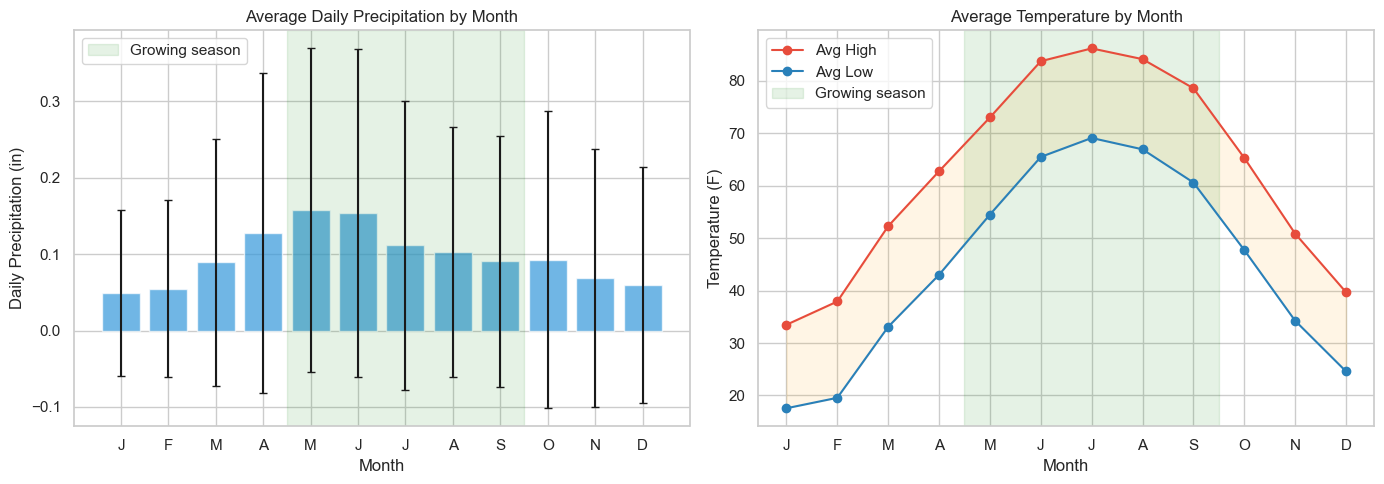

In [6]:
monthly = weather.copy()
monthly['month'] = monthly.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precipitation by month
month_precip = monthly.groupby('month')['precip'].agg(['mean', 'std'])
axes[0].bar(range(1, 13), month_precip['mean'], yerr=month_precip['std'],
            color='#3498db', alpha=0.7, capsize=3)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Daily Precipitation (in)')
axes[0].set_title('Average Daily Precipitation by Month')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].axvspan(4.5, 9.5, alpha=0.1, color='green', label='Growing season')
axes[0].legend()

# Temperature by month
month_temp = monthly.groupby('month')[['temp_max', 'temp_min']].mean()
axes[1].plot(range(1, 13), month_temp['temp_max'], 'o-', color='#e74c3c', label='Avg High')
axes[1].plot(range(1, 13), month_temp['temp_min'], 'o-', color='#2980b9', label='Avg Low')
axes[1].fill_between(range(1, 13), month_temp['temp_min'], month_temp['temp_max'],
                     alpha=0.1, color='orange')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Temperature (F)')
axes[1].set_title('Average Temperature by Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].axvspan(4.5, 9.5, alpha=0.1, color='green', label='Growing season')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Weather x Futures: Looking for Patterns

The central question: does weather data carry information about where corn prices
are going? We align the two datasets and look for relationships.

In [7]:
# Align weather to trading days (futures only trade on business days)
df = prices[['Close']].copy()
df = df.join(weather, how='left')
df[['precip', 'temp_max', 'temp_min']] = df[['precip', 'temp_max', 'temp_min']].ffill()

# Forward returns at different horizons (percentage)
df['ret_1d'] = (df['Close'].shift(-1) / df['Close'] - 1) * 100
df['ret_5d'] = (df['Close'].shift(-5) / df['Close'] - 1) * 100
df['ret_20d'] = (df['Close'].shift(-20) / df['Close'] - 1) * 100

# Train/test split: derive thresholds on 2010-2024, backtest on 2025
TRAIN_END = '2024-12-31'
TEST_START = '2025-01-01'

print(f'Combined dataset: {len(df):,} rows')
print(f'\nTrain/test split:')
print(f'  Train: {len(df.loc[:TRAIN_END]):,} rows '
      f'({df.loc[:TRAIN_END].index.min().date()} to {df.loc[:TRAIN_END].index.max().date()})')
print(f'  Test:  {len(df.loc[TEST_START:]):,} rows '
      f'({df.loc[TEST_START:].index.min().date()} to {df.loc[TEST_START:].index.max().date()})')

print(f'\nForward return stats (%, full dataset):')
summary = pd.DataFrame({
    'mean': df[['ret_1d', 'ret_5d', 'ret_20d']].mean(),
    'median': df[['ret_1d', 'ret_5d', 'ret_20d']].median(),
    'std': df[['ret_1d', 'ret_5d', 'ret_20d']].std(),
    'count': df[['ret_1d', 'ret_5d', 'ret_20d']].count(),
})
print(summary.round(3).to_string())
df.head()

Combined dataset: 4,068 rows

Train/test split:
  Train: 3,770 rows (2010-01-04 to 2024-12-31)
  Test:  298 rows (2025-01-02 to 2026-03-11)

Forward return stats (%, full dataset):
          mean  median    std  count
ret_1d   0.016   0.000  1.714   4067
ret_5d   0.079   0.134  3.799   4063
ret_20d  0.360   0.415  7.756   4048


,Close,temp_max,temp_min,precip,ret_1d,ret_5d,ret_20d
date,,,,,,,
2010-01-04,418.50,5.48,-7.18,0.000000,0.059737,0.955795,-12.783751
2010-01-05,418.75,7.58,-6.28,0.000000,0.716418,-6.268657,-15.701493
2010-01-06,421.75,17.30,-0.22,0.108924,-1.007706,-8.950800,-16.064019
2010-01-07,417.50,12.32,3.14,0.108924,1.317365,-8.742515,-15.808383
2010-01-08,423.00,5.18,-4.54,0.002625,-0.118203,-12.174941,-15.839243


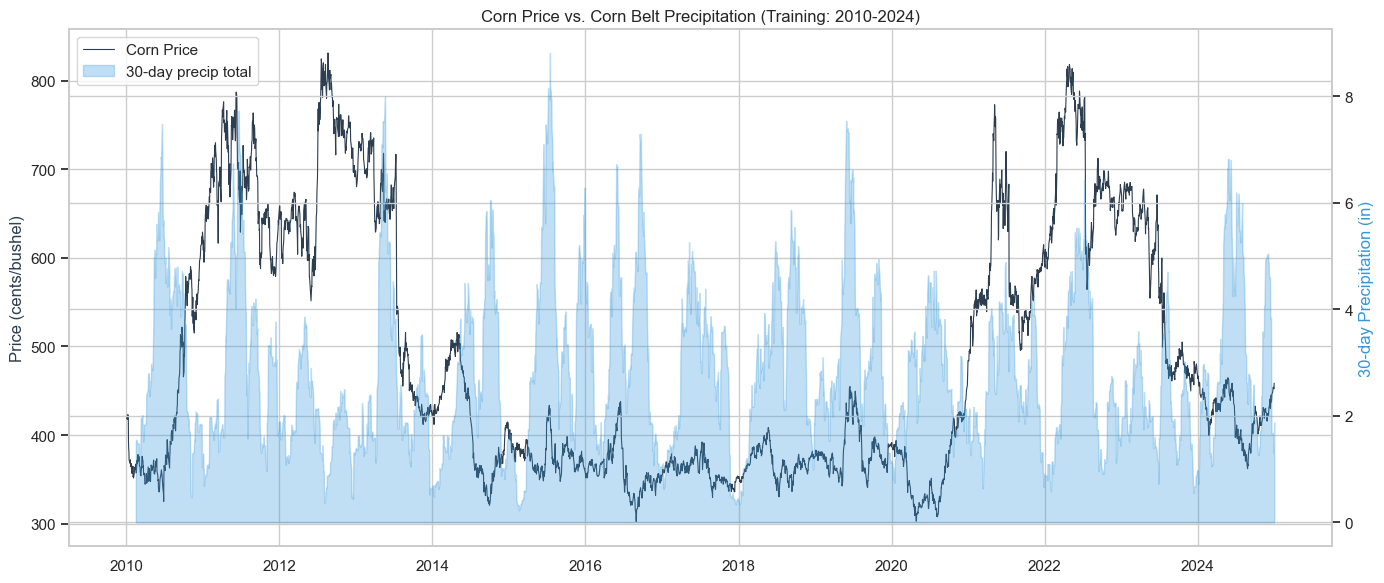

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 6))

train = df.loc[:TRAIN_END]
ax1.plot(train.index, train['Close'], linewidth=0.8, color='#2c3e50', label='Corn Price')
ax1.set_ylabel('Price (cents/bushel)', color='#2c3e50')

ax2 = ax1.twinx()
precip_30d = train['precip'].rolling(30).sum()
ax2.fill_between(train.index, precip_30d, alpha=0.3, color='#3498db', label='30-day precip total')
ax2.set_ylabel('30-day Precipitation (in)', color='#3498db')

ax1.set_title('Corn Price vs. Corn Belt Precipitation (Training: 2010-2024)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 3b. Scatter plots: which precipitation window correlates with price changes?

We compute rolling precipitation sums at 7, 14, 30, and 60-day windows and scatter
each against the 20-day forward price change. The goal is to see if any window shows
a clear relationship, and to check whether that relationship is linear or nonlinear.

### 3a. Visual overlay: price vs. precipitation

Do they move together? A visual check before running any statistics. We overlay the
30-day cumulative precipitation on the price chart to see if there's any visible
co-movement or if price spikes coincide with weather extremes.

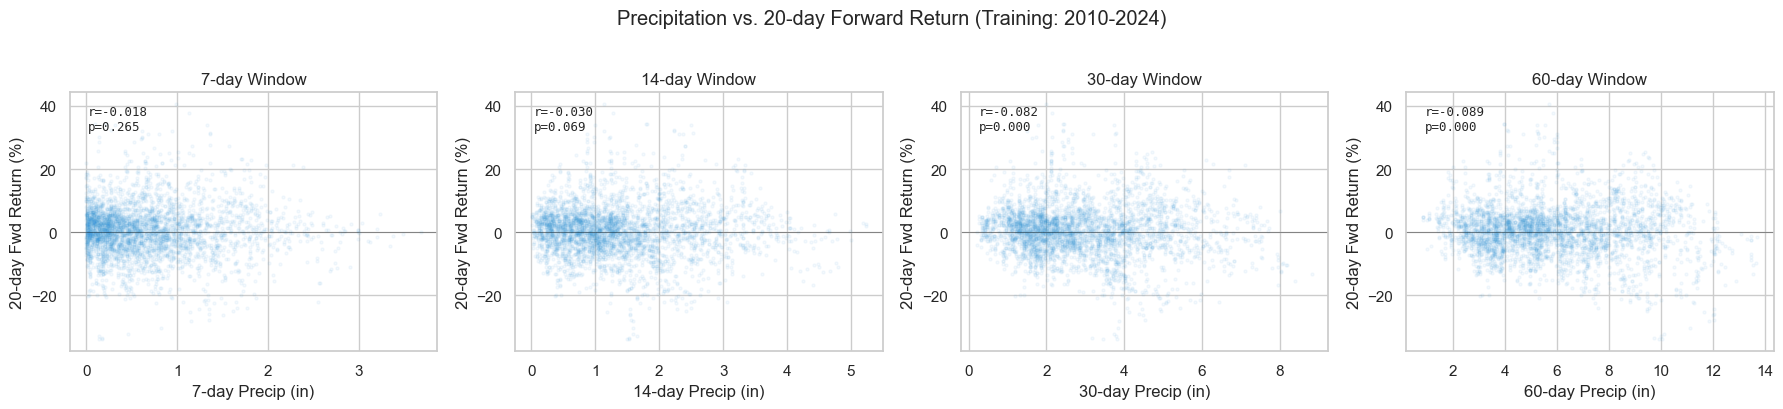

In [9]:
# Compute rolling precipitation on full dataset (rolling windows need history),
# but scatter plots use training data only (2010-2024).
windows = [7, 14, 30, 60]
fig, axes = plt.subplots(1, len(windows), figsize=(18, 4))

for i, w in enumerate(windows):
    col = f'precip_{w}d_raw'
    df[col] = df['precip'].rolling(w).sum().shift(1)  # shift(1) for point-in-time
    valid = df.loc[:TRAIN_END, [col, 'ret_20d']].dropna()

    axes[i].scatter(valid[col], valid['ret_20d'], alpha=0.05, s=5, color='#3498db')
    axes[i].set_xlabel(f'{w}-day Precip (in)')
    axes[i].set_ylabel('20-day Fwd Return (%)')
    axes[i].set_title(f'{w}-day Window')
    axes[i].axhline(0, color='black', linewidth=0.5, alpha=0.5)

    if len(valid) > 2:
        r, p = sp_stats.pearsonr(valid[col], valid['ret_20d'])
        axes[i].text(0.05, 0.95, f'r={r:.3f}\np={p:.3f}', transform=axes[i].transAxes,
                     va='top', fontsize=9, family='monospace')

plt.suptitle('Precipitation vs. 20-day Forward Return (Training: 2010-2024)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Linear correlations between raw precipitation and returns are weak, which is expected.
Weather does not affect prices linearly. A drought (too little rain) and a flood (too
much rain) both hurt crops and push prices *up*. Normal weather means normal supply
and no price pressure.

This means we should look at **extremes and anomalies** rather than raw levels. Below
we construct several candidate features from the raw data and measure their relationship
to returns using both Pearson correlation (linear) and **mutual information** (captures
any statistical dependency, including nonlinear).

In [10]:
# Compute all features on the full dataset -- rolling windows need history.

# ---- Precipitation features ----

# Rolling sums at different horizons
df['precip_7d'] = df['precip'].rolling(7).sum().shift(1)
df['precip_14d'] = df['precip'].rolling(14).sum().shift(1)
df['precip_30d'] = df['precip'].rolling(30).sum().shift(1)

# Z-scores: how abnormal is recent precipitation vs. a rolling baseline?
for w in [30, 60, 90]:
    rolling_mean = df['precip'].rolling(w).mean()
    rolling_std = df['precip'].rolling(w).std()
    df[f'precip_zscore_{w}d'] = ((df['precip'] - rolling_mean) / rolling_std).shift(1)

# Dry-day streak: consecutive days with < 0.01 inches of rain
dry = (df['precip'] < 0.01).astype(int)
df['dry_streak'] = dry.groupby((dry != dry.shift()).cumsum()).cumsum().shift(1)

# ---- Temperature features ----

df['temp_range'] = df['temp_max'] - df['temp_min']
df['temp_max_7d'] = df['temp_max'].rolling(7).mean().shift(1)
df['temp_max_30d'] = df['temp_max'].rolling(30).mean().shift(1)

# Heat stress: days above 95F in the last 7 days
df['heat_days_7d'] = (df['temp_max'] > 95).astype(int).rolling(7).sum().shift(1)

# ---- Combined feature ----

# Drought index: high when precipitation is abnormally low AND temperature is high
df['drought_index'] = (
    -df['precip_zscore_30d'].clip(upper=0) *  # more negative z = drier
    (df['temp_max_7d'] / df['temp_max_7d'].median())  # scaled by temp relative to median
)

feature_cols = [
    'precip_7d', 'precip_14d', 'precip_30d',
    'precip_zscore_30d', 'precip_zscore_60d', 'precip_zscore_90d',
    'dry_streak', 'temp_max_7d', 'temp_max_30d', 'temp_range',
    'heat_days_7d', 'drought_index',
]

# Create train/test split with all features included
df_train = df.loc[:TRAIN_END]
df_test = df.loc[TEST_START:]

print(f'Built {len(feature_cols)} candidate features from raw data')
print(f'Training set: {len(df_train):,} rows | Test set: {len(df_test):,} rows')
df_train[feature_cols].describe().round(3)

Built 12 candidate features from raw data
Training set: 3,770 rows | Test set: 298 rows


,precip_7d,precip_14d,precip_30d,precip_zscore_30d,precip_zscore_60d,precip_zscore_90d,dry_streak,temp_max_7d,temp_max_30d,temp_range,heat_days_7d,drought_index
count,3763.000,3756.000,3740.000,3740.000,3710.000,3680.000,3769.000,3763.000,3740.000,3770.000,3763.000,3740.000
mean,0.670,1.342,2.884,0.011,0.019,0.016,1.290,62.602,62.785,17.572,0.078,0.344
std,0.591,0.928,1.545,1.015,1.040,1.042,2.039,19.487,18.363,5.090,0.452,0.312
min,0.000,0.005,0.226,-1.075,-0.932,-0.823,0.000,8.051,24.098,2.520,0.000,-0.000
25%,0.211,0.640,1.706,-0.549,-0.544,-0.549,0.000,46.010,45.981,14.160,0.000,-0.000
50%,0.518,1.151,2.575,-0.408,-0.415,-0.426,0.000,65.009,65.271,17.460,0.000,0.294
75%,0.957,1.856,3.877,0.133,0.129,0.116,2.000,80.771,80.821,20.760,0.000,0.564
max,3.677,5.239,8.815,5.003,6.885,7.129,15.000,98.171,94.654,39.900,7.000,1.373


### 4. Constructing candidate features

We build features in three categories from raw data:

- **Precipitation features**: rolling sums (how much rain fell recently), z-scores
  (how unusual is recent rain vs. history), and dry-day streaks.
- **Temperature features**: rolling averages, diurnal range, and heat stress counts.
- **Combined features**: drought index that multiplies low-precipitation anomaly by
  high temperature -- the hypothesis being that hot + dry is worse than either alone.

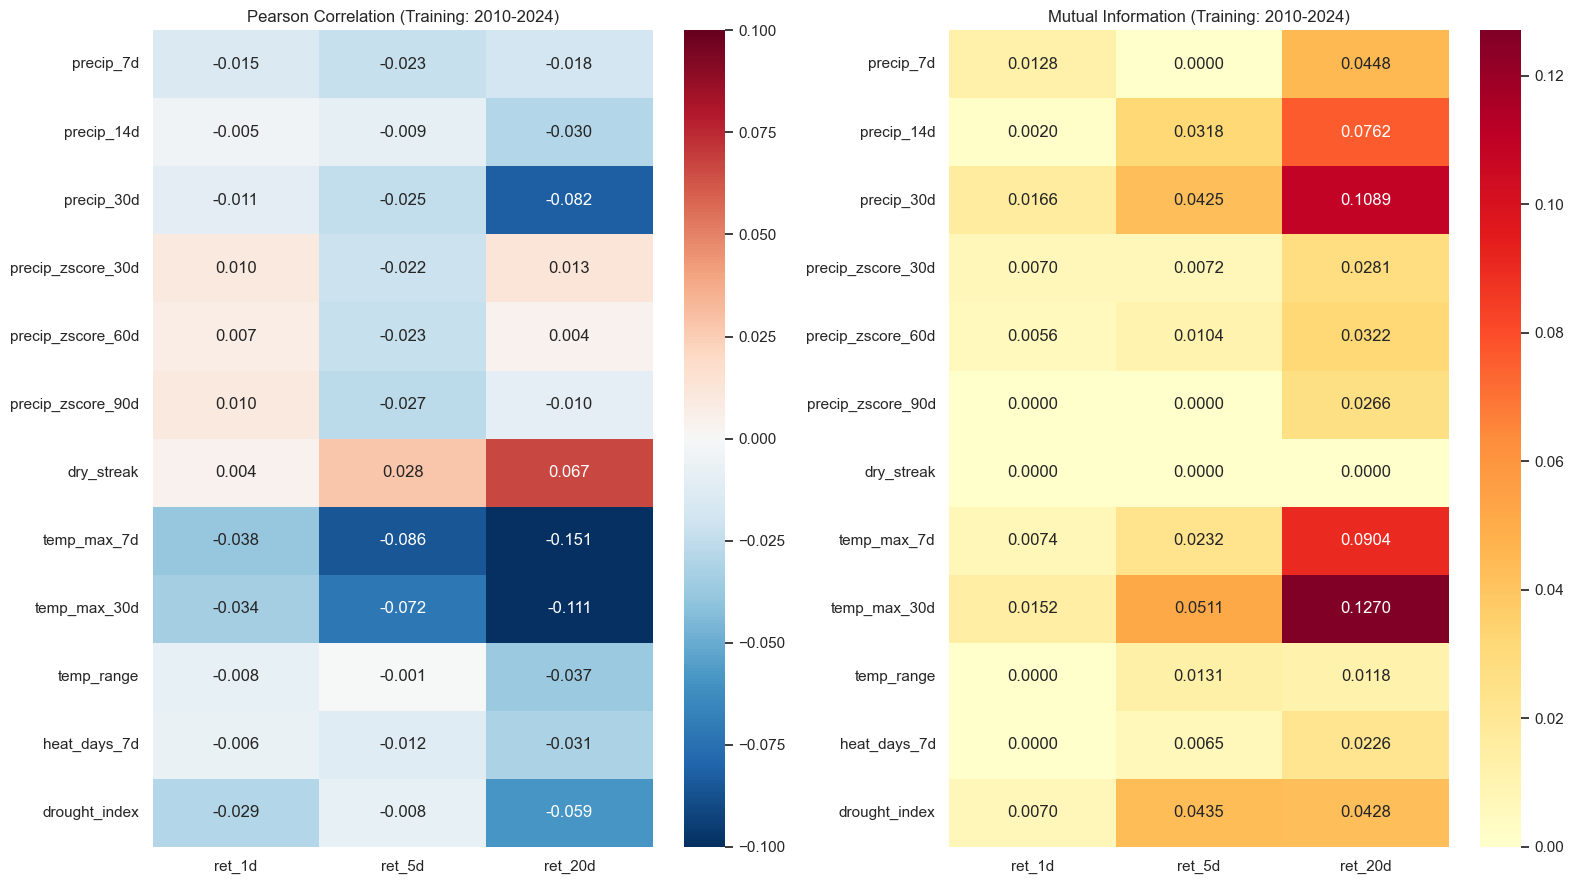

Left: Pearson r near zero -- the relationship is not linear.
Right: MI shows total information content. Higher = more predictive.


In [11]:
# Pearson correlation only captures LINEAR relationships. If both drought
# and flood push prices up, the linear correlation cancels out.
# Mutual information (MI) measures ANY statistical dependence, including nonlinear.
# All analysis uses training data only (2010-2024).

from sklearn.feature_selection import mutual_info_regression

ret_cols = ['ret_1d', 'ret_5d', 'ret_20d']

# --- Linear correlation ---
corr = df_train[feature_cols + ret_cols].corr().loc[feature_cols, ret_cols]

# --- Mutual information ---
mi_results = pd.DataFrame(index=feature_cols, columns=ret_cols, dtype=float)
for rc in ret_cols:
    for fc in feature_cols:
        subset = df_train[[fc, rc]].dropna()
        if len(subset) < 100:
            mi_results.loc[fc, rc] = 0.0
            continue
        mi = mutual_info_regression(
            subset[[fc]], subset[rc], random_state=42, n_neighbors=5
        )
        mi_results.loc[fc, rc] = mi[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.1, vmax=0.1, ax=axes[0])
axes[0].set_title('Pearson Correlation (Training: 2010-2024)')

sns.heatmap(mi_results.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0, ax=axes[1])
axes[1].set_title('Mutual Information (Training: 2010-2024)')

plt.tight_layout()
plt.show()

print('Left: Pearson r near zero -- the relationship is not linear.')
print('Right: MI shows total information content. Higher = more predictive.')

## 5. Testing Extreme Weather Conditions

Linear correlation fails here because the weather-price relationship is fundamentally
nonlinear: both tails (drought and flood) affect supply negatively. We need to look at
what happens to returns *conditioned on* extreme weather.

This is a key difference between ML model evaluation and trading signal evaluation:

- In ML, you check prediction accuracy against a labeled test set.
- In trading, there is no labeled "right answer." You measure whether entering a
  position when conditions are met produces positive expected value after costs
  and risk adjustment.
- A signal can be wrong most of the time and still make money, if the wins are
  large enough to offset the losses.
- With ~4,000 trading days, overfitting is the primary risk. A model that memorizes
  noise will look great in-sample and fail out-of-sample.
- We need a causal story: "drought hurts yield, lower supply pushes prices up" is
  testable and durable. "Feature #47 has p=0.03" is not.

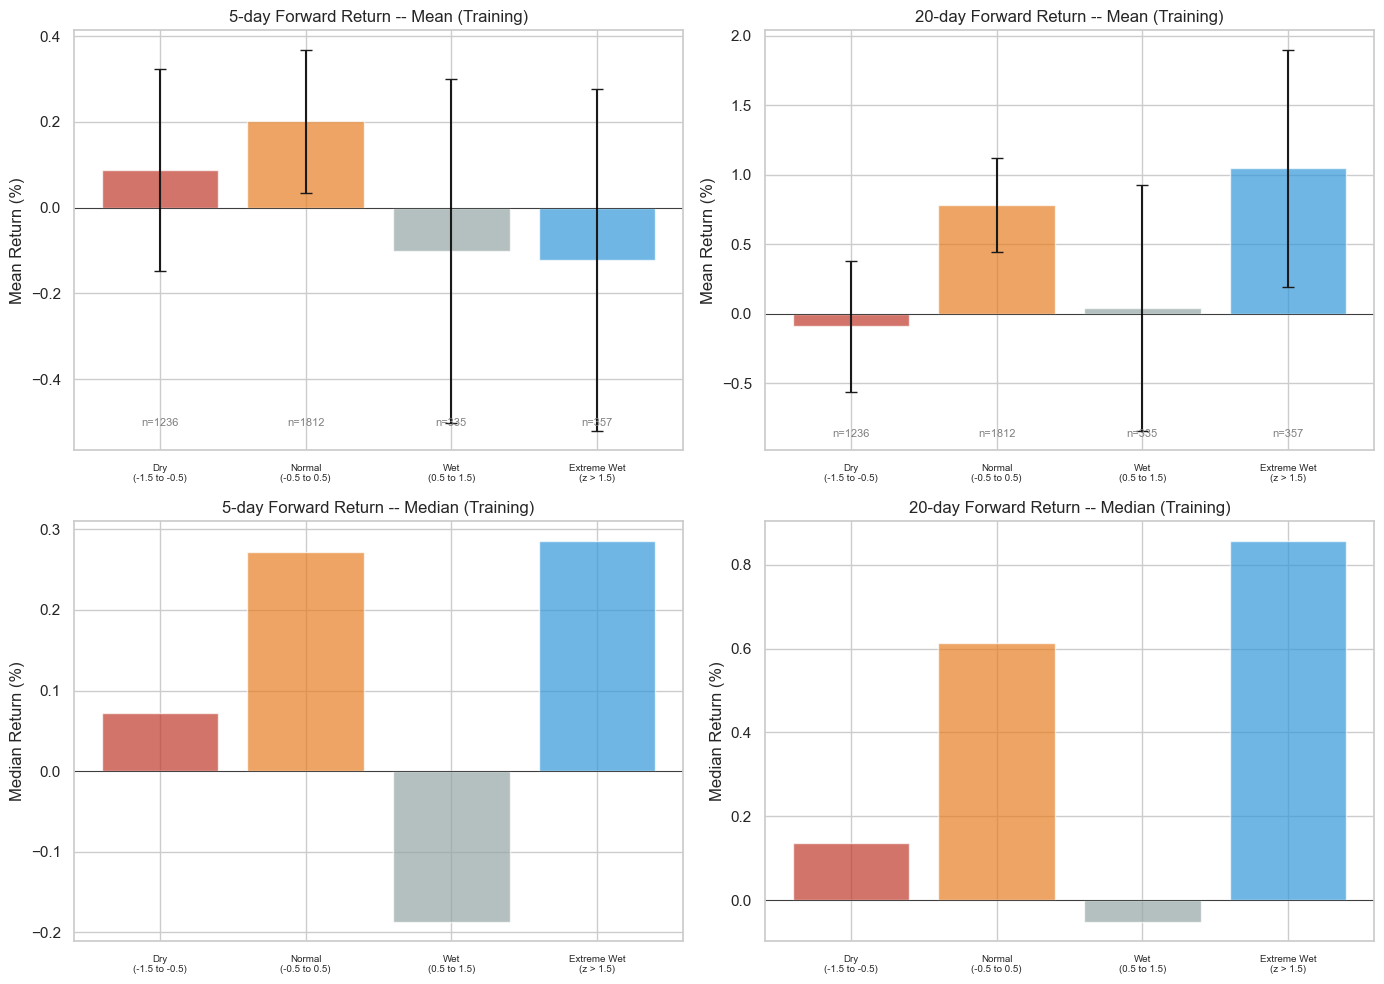

In [12]:
# Bin days by their precipitation z-score and measure the average
# forward return in each bin. Training data only (2010-2024).

analysis = df_train[['precip_zscore_30d', 'ret_5d', 'ret_20d']].dropna()

bins = [-np.inf, -1.5, -0.5, 0.5, 1.5, np.inf]
labels = ['Extreme Dry\n(z < -1.5)', 'Dry\n(-1.5 to -0.5)', 'Normal\n(-0.5 to 0.5)',
          'Wet\n(0.5 to 1.5)', 'Extreme Wet\n(z > 1.5)']
analysis['zone'] = pd.cut(analysis['precip_zscore_30d'], bins=bins, labels=labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_i, ret_col in enumerate(['ret_5d', 'ret_20d']):
    horizon = '5-day' if ret_col == 'ret_5d' else '20-day'
    zone_ret = analysis.groupby('zone', observed=True)[ret_col].agg(['mean', 'median', 'std', 'count'])
    zone_ret['se'] = zone_ret['std'] / np.sqrt(zone_ret['count'])

    colors = ['#c0392b', '#e67e22', '#95a5a6', '#3498db', '#2c3e50']

    axes[0, col_i].bar(range(len(zone_ret)), zone_ret['mean'],
                yerr=zone_ret['se'] * 1.96, capsize=4,
                color=colors, alpha=0.7)
    axes[0, col_i].set_xticks(range(len(zone_ret)))
    axes[0, col_i].set_xticklabels(zone_ret.index, fontsize=7)
    axes[0, col_i].axhline(0, color='black', linewidth=0.5)
    axes[0, col_i].set_ylabel('Mean Return (%)')
    axes[0, col_i].set_title(f'{horizon} Forward Return -- Mean (Training)')
    for j, (_, row) in enumerate(zone_ret.iterrows()):
        axes[0, col_i].text(j, axes[0, col_i].get_ylim()[0] * 0.9,
                     f'n={int(row["count"])}', ha='center', fontsize=8, color='gray')

    axes[1, col_i].bar(range(len(zone_ret)), zone_ret['median'],
                color=colors, alpha=0.7)
    axes[1, col_i].set_xticks(range(len(zone_ret)))
    axes[1, col_i].set_xticklabels(zone_ret.index, fontsize=7)
    axes[1, col_i].axhline(0, color='black', linewidth=0.5)
    axes[1, col_i].set_ylabel('Median Return (%)')
    axes[1, col_i].set_title(f'{horizon} Forward Return -- Median (Training)')

plt.tight_layout()
plt.show()

### 5a. Conditional price changes by precipitation zone

Instead of asking "what is the correlation?", we ask a more direct question: "when
precipitation is extremely low, what happens to prices over the next 5 and 20 days?"

We bin days into five zones based on the 30-day precipitation z-score, then compute
the average forward price change in each zone. If extreme zones show meaningfully
different behavior from the normal zone, that is a potential signal.

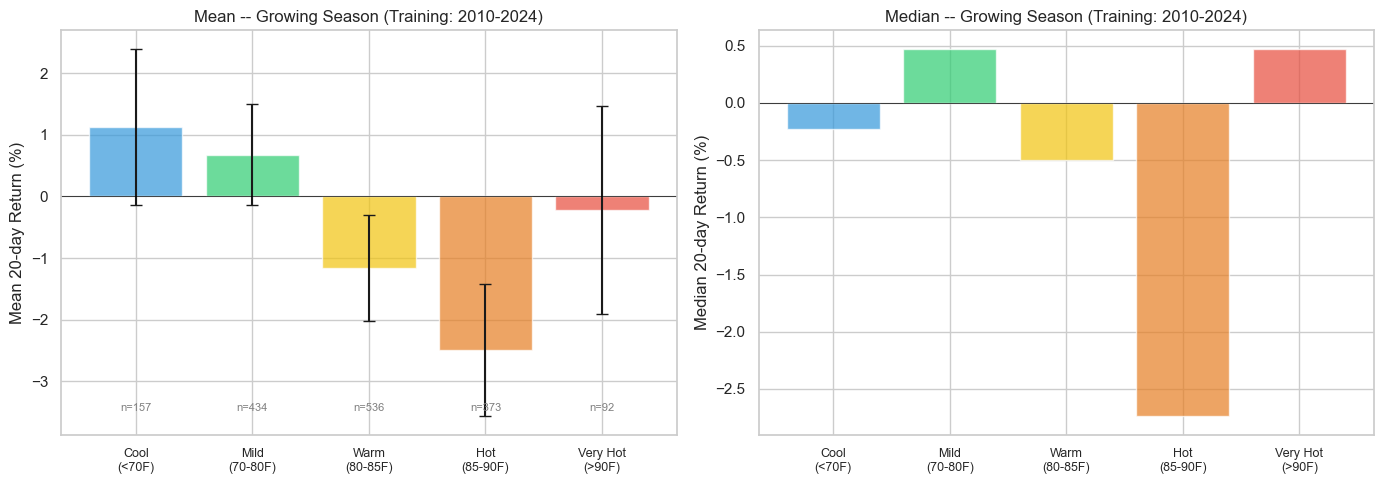

In [13]:
# Temperature analysis restricted to the growing season (May-Sep)
# Training data only (2010-2024)

analysis_t = df_train[['temp_max_7d', 'ret_20d']].dropna()
growing = analysis_t[analysis_t.index.month.isin([5, 6, 7, 8, 9])].copy()

bins_t = [0, 70, 80, 85, 90, 120]
labels_t = ['Cool\n(<70F)', 'Mild\n(70-80F)', 'Warm\n(80-85F)',
            'Hot\n(85-90F)', 'Very Hot\n(>90F)']
growing['temp_zone'] = pd.cut(growing['temp_max_7d'], bins=bins_t, labels=labels_t)

zone_ret = growing.groupby('temp_zone', observed=True)['ret_20d'].agg(['mean', 'median', 'std', 'count'])
zone_ret['se'] = zone_ret['std'] / np.sqrt(zone_ret['count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_t = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

axes[0].bar(range(len(zone_ret)), zone_ret['mean'],
       yerr=zone_ret['se'] * 1.96, capsize=4, color=colors_t, alpha=0.7)
axes[0].set_xticks(range(len(zone_ret)))
axes[0].set_xticklabels(zone_ret.index, fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Mean 20-day Return (%)')
axes[0].set_title('Mean -- Growing Season (Training: 2010-2024)')
for j, (_, row) in enumerate(zone_ret.iterrows()):
    axes[0].text(j, axes[0].get_ylim()[0] * 0.9, f'n={int(row["count"])}',
            ha='center', fontsize=8, color='gray')

axes[1].bar(range(len(zone_ret)), zone_ret['median'],
       color=colors_t, alpha=0.7)
axes[1].set_xticks(range(len(zone_ret)))
axes[1].set_xticklabels(zone_ret.index, fontsize=9)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Median 20-day Return (%)')
axes[1].set_title('Median -- Growing Season (Training: 2010-2024)')

plt.tight_layout()
plt.show()

### 5b. Temperature conditional analysis (growing season only)

Temperature should only matter during the growing season (May-September) when corn
is actively developing. Extreme heat during pollination (July-August) can permanently
reduce yield. We check whether hot-temperature days show different forward price
behavior than mild-temperature days.

In [14]:
# Does combining precipitation and temperature give a stronger signal?
# Training data only (2010-2024)

combo = df_train[['precip_zscore_30d', 'temp_max_7d', 'ret_20d']].dropna()
combo = combo[combo.index.month.isin([5, 6, 7, 8, 9])].copy()  # growing season

combo['precip_regime'] = 'normal'
combo.loc[combo['precip_zscore_30d'] < -0.8, 'precip_regime'] = 'dry'
combo.loc[combo['precip_zscore_30d'] > 1.5, 'precip_regime'] = 'wet'

combo['temp_regime'] = 'normal'
combo.loc[combo['temp_max_7d'] > 85, 'temp_regime'] = 'hot'
combo.loc[combo['temp_max_7d'] < 70, 'temp_regime'] = 'cool'

pivot = combo.groupby(['precip_regime', 'temp_regime'])['ret_20d'].agg(['mean', 'median', 'count'])

print('20-day Forward Return (%) by Weather Regime  [Growing Season, Training: 2010-2024]')
print('=' * 75)
print(pivot.round(2).to_string())

if len(pivot) > 0:
    best = pivot['median'].idxmax()
    worst = pivot['median'].idxmin()
    print(f'\nHighest median return: {best[0]} precip + {best[1]} temp '
          f'(median {pivot.loc[best, "median"]:.2f}%, '
          f'mean {pivot.loc[best, "mean"]:.2f}%, '
          f'n={int(pivot.loc[best, "count"])})')
    print(f'Lowest median return:  {worst[0]} precip + {worst[1]} temp '
          f'(median {pivot.loc[worst, "median"]:.2f}%, '
          f'mean {pivot.loc[worst, "mean"]:.2f}%, '
          f'n={int(pivot.loc[worst, "count"])})')

20-day Forward Return (%) by Weather Regime  [Growing Season, Training: 2010-2024]
                            mean  median  count
precip_regime temp_regime                      
dry           cool          2.60    2.32      4
              hot         -11.11  -17.58     18
              normal        0.46    1.44     78
normal        cool          0.67   -0.56    137
              hot          -1.67   -2.20    399
              normal       -0.54   -0.57    811
wet           cool          4.69    2.69     16
              hot          -1.75   -1.95     48
              normal        0.94    1.87     81

Highest median return: wet precip + cool temp (median 2.69%, mean 4.69%, n=16)
Lowest median return:  dry precip + hot temp (median -17.58%, mean -11.11%, n=18)


## 6. Threshold Sensitivity

A common trap in strategy development is finding thresholds that fit the data perfectly
but do not generalize. We want to check whether the precipitation anomaly pattern holds
across a reasonable range of threshold values, not just one lucky pair.

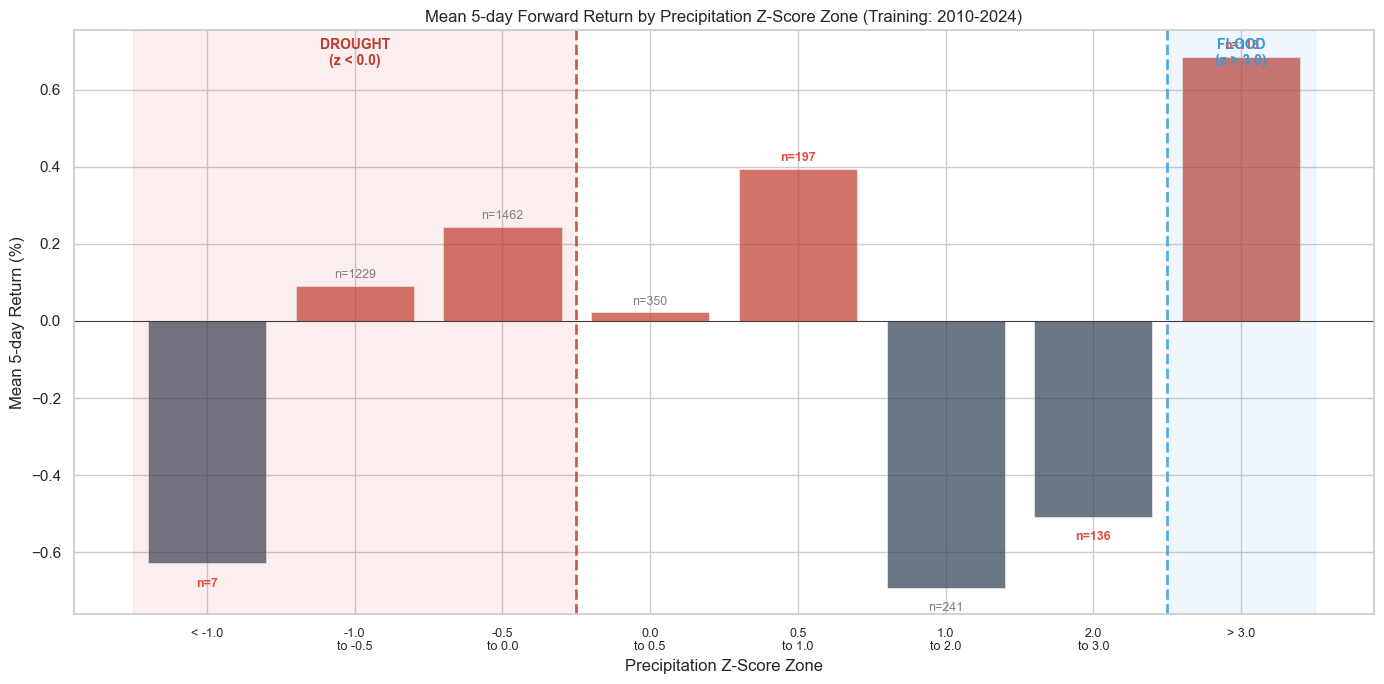

Zone Summary (Training: 2010-2024):
Zone               Mean   Median   Count  Note
-------------------------------------------------------
< -1.0          -0.629%  -0.080%       7  ** small sample  [drought]
-1.0 to -0.5    +0.092%  +0.073%    1229  [drought]
-0.5 to 0.0     +0.245%  +0.360%    1462  [drought]
0.0 to 0.5      +0.022%  -0.100%     350
0.5 to 1.0      +0.394%  +0.000%     197  ** small sample
1.0 to 2.0      -0.693%  -0.209%     241
2.0 to 3.0      -0.508%  -0.590%     136  ** small sample
> 3.0           +0.685%  +0.857%     118  ** small sample  [flood]


In [15]:
# Full-spectrum view with wider bins for clearer patterns.
# Training data only (2010-2024) -- thresholds derived here, tested out-of-sample.

valid_sweep = df_train[['precip_zscore_30d', 'ret_5d']].dropna()

bin_edges = [-np.inf, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0, np.inf]
bin_labels = ['< -1.0', '-1.0\nto -0.5', '-0.5\nto 0.0', '0.0\nto 0.5',
              '0.5\nto 1.0', '1.0\nto 2.0', '2.0\nto 3.0', '> 3.0']
valid_sweep['bin'] = pd.cut(valid_sweep['precip_zscore_30d'], bins=bin_edges, labels=bin_labels)
binned = valid_sweep.groupby('bin', observed=True)['ret_5d'].agg(['mean', 'median', 'count'])

fig, ax = plt.subplots(figsize=(14, 7))

colors_bin = ['#c0392b' if m > 0 else '#2c3e50' for m in binned['mean']]
bars = ax.bar(range(len(binned)), binned['mean'], color=colors_bin, alpha=0.7,
              edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(binned)))
ax.set_xticklabels(binned.index, fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Precipitation Z-Score Zone')
ax.set_ylabel('Mean 5-day Return (%)')
ax.set_title('Mean 5-day Forward Return by Precipitation Z-Score Zone (Training: 2010-2024)')

# Show sample sizes on each bar -- highlight small samples
for j, (_, row) in enumerate(binned.iterrows()):
    n = int(row['count'])
    color = '#e74c3c' if n < 200 else 'gray'
    weight = 'bold' if n < 200 else 'normal'
    y_pos = row['mean'] + 0.02 if row['mean'] >= 0 else row['mean'] - 0.06
    ax.text(j, y_pos, f'n={n}', ha='center', fontsize=9, color=color, fontweight=weight)

# Shade drought zone (bins 0-2: z < 0.0)
ax.axvspan(-0.5, 2.5, alpha=0.08, color='#c0392b')
ax.axvline(2.5, color='#c0392b', linewidth=2, linestyle='--', alpha=0.8)
ax.text(1.0, ax.get_ylim()[1] * 0.88, 'DROUGHT\n(z < 0.0)',
        ha='center', fontsize=10, color='#c0392b', fontweight='bold')

# Shade flood zone (bin 7 only: z > 3.0)
ax.axvspan(6.5, len(binned) - 0.5, alpha=0.08, color='#3498db')
ax.axvline(6.5, color='#3498db', linewidth=2, linestyle='--', alpha=0.8)
ax.text(7.0, ax.get_ylim()[1] * 0.88, 'FLOOD\n(z > 3.0)',
        ha='center', fontsize=10, color='#3498db', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print('Zone Summary (Training: 2010-2024):')
print(f'{"Zone":<14} {"Mean":>8} {"Median":>8} {"Count":>7}  Note')
print('-' * 55)
for label, row in binned.iterrows():
    n = int(row['count'])
    note = ''
    if n < 200:
        note = f'  ** small sample'
    if label in ['< -1.0', '-1.0\nto -0.5', '-0.5\nto 0.0']:
        note += '  [drought]'
    elif label in ['> 3.0']:
        note += '  [flood]'
    clean_label = str(label).replace('\n', ' ')
    print(f'{clean_label:<14} {row["mean"]:>+7.3f}% {row["median"]:>+7.3f}% {n:>7}{note}')

## 6. Thesis & Signal Design

### How the feature is computed

The signal uses a single feature: the 30-day precipitation z-score.

Raw daily precipitation (inches) --> 30-day rolling mean & std --> z-score = (value - mean) / std

In this notebook we compute it inline as `precip_zscore_30d`. In the production
feature store, the identical computation is called `precip_anomaly_30d` (defined in
`features/compute/weather.py:rolling_zscore()`). The strategy reads it as
`corn_belt_precip_anomaly_30d` -- the Corn Belt aggregate (mean of Iowa, Illinois,
Nebraska). Same formula, different names at different layers.

### Our thesis

Extreme precipitation anomalies -- both drought and flood -- threaten corn supply.
When supply is threatened, prices tend to rise. When weather is normal, there is no
supply pressure and prices drift or decline.

### How we arrived at the signal

All EDA and threshold derivation used **training data only (2010-2024)**.
The backtest runs on **2025 out-of-sample data**, matching the app's backtester
behavior.

From the analysis above:

1. **Feature selection**: The mutual information analysis (section 4) identified
   **`precip_zscore_30d` as the weather feature with the most statistical dependence
   on forward returns**. It normalizes recent rainfall against its own history, making
   it comparable across seasons.

2. **Threshold selection** (data-driven from the sweep in section 5):
   - **Drought: z < 0.0** -- all three bins below zero show positive mean returns,
     with the -0.5 to 0.0 bin providing the strongest evidence (n=1,462, mean +0.25%,
     median +0.36%). Below-average precipitation = supply concern.
   - **Flood: z > 3.0** -- the 2.0 to 3.0 bin has negative returns (n=136, mean
     -0.51%) and should not be included. Only the extreme wet bin (z > 3.0, n=118,
     mean +0.69%) shows the expected flood premium.

3. **Normal zone**: When **0.0 < z < 0.3**, weather is unremarkable -- no supply
   threat. This is our short signal.

4. **Transition zones**: Between 0.3 and 3.0, conditions are ambiguous. We stay flat.

The evidence for this signal is weak -- the EDA showed noisy patterns, not a clean edge.
We are building this strategy primarily to **test the backtesting engine end-to-end**:
feature store query, signal generation, position sizing, P&L, trade logging, and
performance metrics. It is a proof of concept, not a production signal.

### Signal evaluation metrics

| Metric | What It Measures |
|--------|------------------|
| **Sharpe Ratio** | Risk-adjusted return (annualized mean/std of daily P&L) |
| **Win Rate** | Fraction of profitable trades |
| **Profit Factor** | Gross wins / gross losses |
| **Max Drawdown** | Largest peak-to-trough equity decline |
| **Number of Trades** | Sample size |

### Backtesting assumptions

All backtest results in this notebook (precipitation signal, SMA crossover, and mean
reversion baselines) use identical settings for a fair comparison:

- **Starting capital**: $100M
- **Transaction costs**: $0 per trade (no slippage, no commissions). This overstates
  performance because real execution costs would reduce returns. Configurable via the
  `cost_per_trade` parameter in `run_backtest()`.
- **Position sizing**: 1% of current equity allocated per trade (`risk_pct=0.01`).
  Units = allocation / price. No pyramiding (consecutive same direction signals hold
  the same position size).
- **Execution**: Signals are computed and executed on the same day. Features are
  already point in time (lagged by 1 day in the feature pipeline), so there is no
  lookahead bias from the features themselves.
- **No margin or leverage**: Positions are funded from equity only.

In [21]:
# Signal derived from the threshold analysis above (thresholds from training data):
# - Long when precipitation z-score indicates drought (z < 0.0) or flood (z > 3.0)
# - Short when precipitation is normal (0.0 < z < 0.3)
# - Flat in transition zones

DROUGHT = 0.0
FLOOD = 3.0
NORMAL_LOW = 0.0
NORMAL_HIGH = 0.3

def generate_precip_signal(input_df):
    out = input_df.copy()
    z = out['precip_zscore_30d']
    out['signal'] = 0
    out.loc[z < DROUGHT, 'signal'] = 1        # drought -> long
    out.loc[z > FLOOD, 'signal'] = 1           # flood -> long
    out.loc[(z > NORMAL_LOW) & (z < NORMAL_HIGH), 'signal'] = -1  # normal -> short
    out.loc[z.isna(), 'signal'] = 0
    return out

# Backtest on 2025 test data only (out-of-sample)
signal_df = generate_precip_signal(df_test)
result, trade_log, stats = run_backtest(signal_df, capital=100_000_000, risk_pct=0.01)

print('=== Precipitation Anomaly Signal (2025 Out-of-Sample) ===')
print(f'Backtest period: {df_test.index.min().date()} to {df_test.index.max().date()}')
print(f'Total P&L:       ${stats["total_pnl"]:>14,.0f}')
print(f'Total Return:    {stats["total_return_pct"]:>13.2f}%')
print(f'Sharpe Ratio:    {stats["sharpe_ratio"]:>13.2f}')
print(f'Sortino Ratio:   {stats["sortino_ratio"]:>13.2f}')
print(f'Max Drawdown:    {stats["max_drawdown_pct"]:>13.2f}%')
print(f'Win Rate:        {stats["win_rate"]*100:>13.1f}%')
print(f'Profit Factor:   {stats["profit_factor"]:>13.2f}')
print(f'Num Trades:      {stats["num_trades"]:>13d}')
print(f'Avg Holding:     {stats["avg_holding_days"]:>13.1f} days')

=== Precipitation Anomaly Signal (2025 Out-of-Sample) ===
Backtest period: 2025-01-02 to 2026-03-11
Total P&L:       $       228,016
Total Return:             0.23%
Sharpe Ratio:             1.04
Sortino Ratio:            1.52
Max Drawdown:            -0.10%
Win Rate:                 54.8%
Profit Factor:            1.59
Num Trades:                 62
Avg Holding:               5.9 days


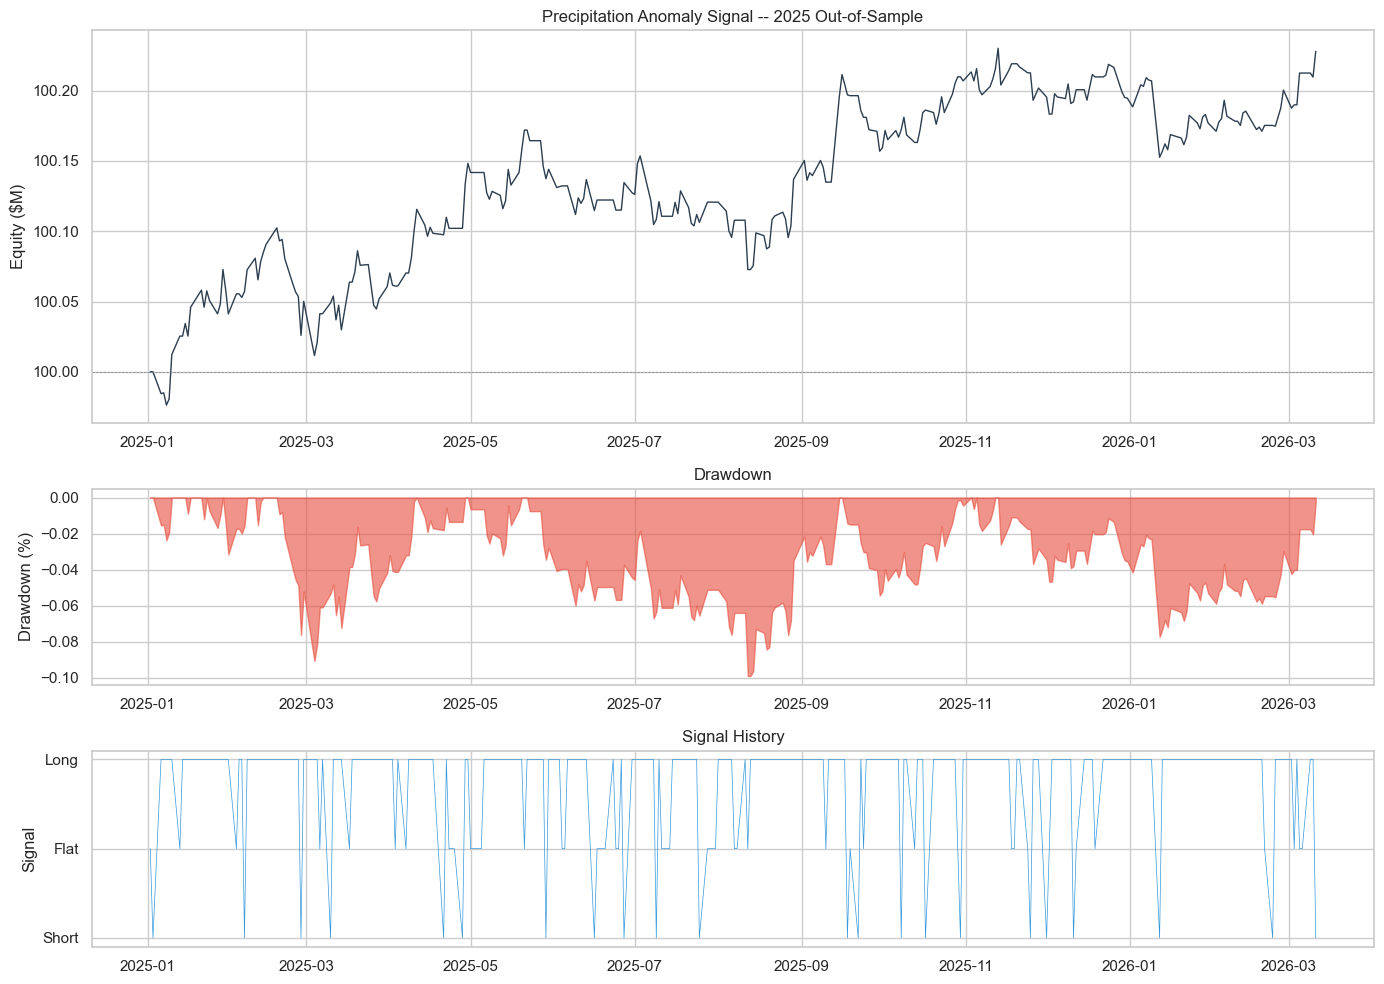

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

# Equity curve
axes[0].plot(result.index, result['equity'] / 1e6, linewidth=1, color='#2c3e50')
axes[0].axhline(100, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Equity ($M)')
axes[0].set_title('Precipitation Anomaly Signal -- 2025 Out-of-Sample')

# Drawdown
running_max = result['equity'].cummax()
drawdown_pct = (result['equity'] - running_max) / running_max * 100
axes[1].fill_between(result.index, drawdown_pct, alpha=0.6, color='#e74c3c')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown')

# Signal
axes[2].plot(result.index, result['signal'], linewidth=0.5, color='#3498db')
axes[2].set_ylabel('Signal')
axes[2].set_yticks([-1, 0, 1])
axes[2].set_yticklabels(['Short', 'Flat', 'Long'])
axes[2].set_title('Signal History')

plt.tight_layout()
plt.show()

In [24]:
# Testing on different periods

periods = [
    ('Train 2010-2021, Test 2022', '2022-01-01', '2022-12-31'),
    ('Train 2010-2022, Test 2023', '2023-01-01', '2023-12-31'),
    ('Train 2010-2023, Test 2024', '2024-01-01', '2024-12-31'),
    ('Train 2010-2024, Test 2025', '2025-01-01', '2025-12-31'),
]

print('=== Walk-Forward (expanding window, fixed thresholds) ===')
print(f'{"":<32} {"Sharpe":>8} {"Return %":>10} {"Win Rate":>10} {"Trades":>8} {"Max DD %":>10}')
print('-' * 80)

for label, start, end in periods:
    sub = df.loc[start:end].copy()
    if len(sub) < 20:
        continue
    sub = generate_precip_signal(sub)
    r, tl, s = run_backtest(sub, capital=100_000_000, risk_pct=0.01)
    print(f'{label:<32} {s["sharpe_ratio"]:>8.2f} {s["total_return_pct"]:>10.2f} '
          f'{s["win_rate"]*100:>9.1f}% {s["num_trades"]:>8d} {s["max_drawdown_pct"]:>10.2f}')

=== Walk-Forward (expanding window, fixed thresholds) ===
                                   Sharpe   Return %   Win Rate   Trades   Max DD %
--------------------------------------------------------------------------------
Train 2010-2021, Test 2022           0.17       0.05      59.0%       61      -0.32
Train 2010-2022, Test 2023           0.56       0.16      50.0%       54      -0.19
Train 2010-2023, Test 2024          -2.14      -0.39      38.8%       49      -0.52
Train 2010-2024, Test 2025           1.04       0.19      52.7%       55      -0.10


## 8. Comparison Baseline: Momentum and Mean Reversion

We compare the weather signal against two standard technical baselines. These are
not meant to be strong implementations of trend following or mean reversion. They
exist for two reasons:

1. **Comparison**: Does the weather signal add anything beyond what price alone provides?
   Even simple baselines give us a reference point.
2. **MVP prototype**: Testing multiple strategies side by side exercises the full
   backtesting pipeline (signal generation, position sizing, P&L, metrics). These
   baselines are a proof of concept for how the platform will look when we add more
   strategies later.

***

### Baseline 1: SMA 20/50 Crossover (Trend Following)

**What it computes:** Two Simple Moving Averages of the closing price, a fast one
(20 day) and a slow one (50 day). Each SMA is the average closing price over
the last N days.

**Signal logic:**
- SMA_20 > SMA_50 → recent prices above the longer term trend → go long (+1)
- SMA_20 < SMA_50 → recent prices below the longer term trend → go short (−1)

***

### Baseline 2: Mean Reversion (20 Day Z Score)

**What it computes:** A z score of today's close price relative to the last 20
trading days. z = (today's close − 20 day mean) / 20 day std. This measures how
many standard deviations the current price is from its recent average.

**Signal logic:**
- z < −1.5 → price is 1.5 std devs below its recent average → go long (+1)
- z > +1.5 → price is 1.5 std devs above its recent average → go short (−1)
- −1.5 ≤ z ≤ 1.5 → price is within normal range → flat (0)

In [ ]:
# === Baseline 1: SMA 20/50 Crossover (Trend Following) ===
# Compute indicators on full dataset (need history for rolling windows),
# then filter to 2025 for a fair comparison.

sma_df = df[['Close']].copy()

# Step 1: Compute the fast (20 day) and slow (50 day) simple moving averages
sma_df['sma_20'] = df['Close'].rolling(20).mean()
sma_df['sma_50'] = df['Close'].rolling(50).mean()

# Step 2: Generate signal based on crossover
# SMA_20 > SMA_50 means recent prices are above the longer term trend -> bullish -> long
# SMA_20 < SMA_50 means recent prices are below the longer term trend -> bearish -> short
sma_df['signal'] = 0
valid = sma_df['sma_20'].notna() & sma_df['sma_50'].notna()
sma_df.loc[valid & (sma_df['sma_20'] > sma_df['sma_50']), 'signal'] = 1   # trending up -> long
sma_df.loc[valid & (sma_df['sma_20'] < sma_df['sma_50']), 'signal'] = -1  # trending down -> short

# Step 3: Filter to test period only
sma_df = sma_df.loc[TEST_START:]

sma_result, sma_trades, sma_stats = run_backtest(sma_df, capital=100_000_000, risk_pct=0.01)

# === Baseline 2: Mean Reversion (20 Day Z Score) ===
# z = (close − 20 day mean) / 20 day std
# Measures how many std devs today's price is from its recent average.

mr_df = df[['Close']].copy()

# Step 1: Compute z score of closing price over a 20 day rolling window
zscore_mr = (df['Close'] - df['Close'].rolling(20).mean()) / df['Close'].rolling(20).std()

# Step 2: Generate signal based on z score thresholds
# z < −1.5: price is far below recent average ("oversold") -> expect reversion up -> long
# z > +1.5: price is far above recent average ("overbought") -> expect reversion down -> short
# −1.5 <= z <= 1.5: price is near its recent average -> no trade -> flat
mr_df['signal'] = 0
valid_z = zscore_mr.notna()
mr_df.loc[valid_z & (zscore_mr < -1.5), 'signal'] = 1    # oversold -> long
mr_df.loc[valid_z & (zscore_mr > 1.5), 'signal'] = -1     # overbought -> short

# Step 3: Filter to test period only
mr_df = mr_df.loc[TEST_START:]

mr_result, mr_trades, mr_stats = run_backtest(mr_df, capital=100_000_000, risk_pct=0.01)

# === Comparison Table ===
# SMA Crossover: trend following (go with the trend)
# Mean Reversion: contrarian (bet against extremes)
# Precip Anomaly: weather fundamental (trade on supply risk from weather)
rows = ['Sharpe', 'Return (%)', 'Win Rate (%)', 'Max DD (%)', 'Trades', 'Profit Factor']
comparison = pd.DataFrame({
    'SMA Crossover': [
        f'{sma_stats["sharpe_ratio"]:.2f}', f'{sma_stats["total_return_pct"]:.2f}',
        f'{sma_stats["win_rate"]*100:.1f}', f'{sma_stats["max_drawdown_pct"]:.2f}',
        sma_stats["num_trades"], f'{sma_stats["profit_factor"]:.2f}',
    ],
    'Mean Reversion': [
        f'{mr_stats["sharpe_ratio"]:.2f}', f'{mr_stats["total_return_pct"]:.2f}',
        f'{mr_stats["win_rate"]*100:.1f}', f'{mr_stats["max_drawdown_pct"]:.2f}',
        mr_stats["num_trades"], f'{mr_stats["profit_factor"]:.2f}',
    ],
    'Precip Anomaly': [
        f'{stats["sharpe_ratio"]:.2f}', f'{stats["total_return_pct"]:.2f}',
        f'{stats["win_rate"]*100:.1f}', f'{stats["max_drawdown_pct"]:.2f}',
        stats["num_trades"], f'{stats["profit_factor"]:.2f}',
    ],
}, index=rows)

print('=== Strategy Comparison (2025 Out of Sample) ===')
print('SMA Crossover = trend following | Mean Reversion = contrarian | Precip Anomaly = weather fundamental')
print()
print(comparison.to_string())